# Project 1: Fast Food Marketing Campaign A/B Test

## Scenario
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

## Goal
Evaluate A/B testing results and decide which marketing strategy works the best.

## Columns
- **MarketID**: unique identifier for market
- **MarketSize**: size of market area by sales
- **LocationID**: unique identifier for store location
- **AgeOfStore**: age of store in years
- **Promotion**: one of three promotions that were tested
- **week**: one of four weeks when the promotions were run
- **SalesInThousands**: sales amount for a specific LocationID, Promotion, and week


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_path = Path('./WA_Marketing-Campaign.csv')  
print(data_path.resolve())
print(data_path.exists())

df = pd.read_csv(data_path)
df.sample(5)


C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C2\M4\Project-1\WA_Marketing-Campaign.csv
True


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
521,10,Large,914,9,2,2,43.44
74,2,Small,106,5,3,3,53.14
103,3,Large,207,1,3,4,94.21
4,1,Medium,2,5,2,1,27.81
273,6,Medium,504,4,1,2,36.80


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


In [13]:
df =df.drop(columns=['MarketID','MarketSize','LocationID','AgeOfStore','week'])
df.sample(5)


,Promotion,SalesInThousands
490,2,51.35
228,2,47.33
478,3,54.33
545,2,45.75
523,2,45.90


<Axes: xlabel='Promotion', ylabel='SalesInThousandsAvg'>

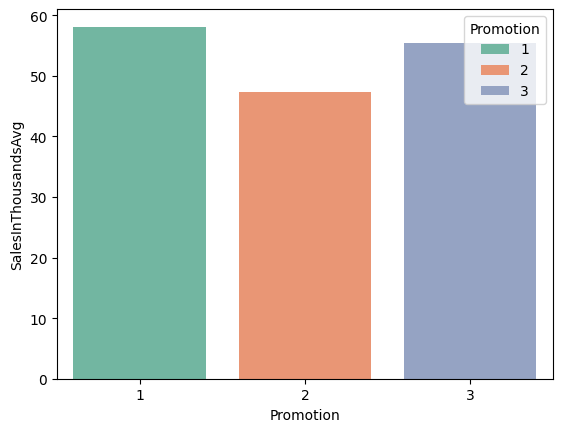

In [ ]:
# Calculate average sales for each promotion
avg_sales = df.groupby('Promotion')['SalesInThousands'].mean().reset_index()
avg_sales = avg_sales.rename(columns={'SalesInThousands': 'SalesInThousandsAvg'})
avg_sales
# Plotting the average sales for each promotion
sns.barplot(x='Promotion', y='SalesInThousandsAvg', data=avg_sales ,hue='Promotion', palette='Set2')

C:\Users\xxslo\AppData\Local\Temp\ipykernel_19460\272410702.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Promotion', y='SalesInThousands', data=df, kind='box', palette='Set2')


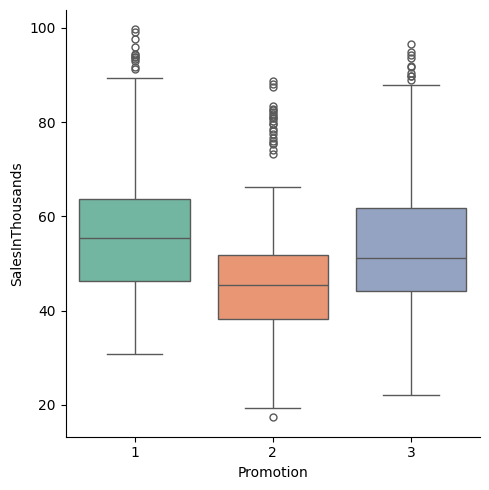

In [26]:
sns.catplot(x='Promotion', y='SalesInThousands', data=df, kind='box', palette='Set2')

In [23]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

alpha = 0.05

tukey = pairwise_tukeyhsd(endog=df['SalesInThousands'], groups=df['Promotion'], alpha=alpha)

print(tukey)
print("significant!" if (tukey.reject.any()) else "not enough evidence")



 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------
significant!
